# **11766 Advanced Perception for Mobile Robotics**
## Master's Degree in Intelligent Systems
### University of the Balearic Islands
---

##### Write in the following the names of the members of the group:
- Marta González Juan
- Pau Girón Rodríguez

## **Instructions**

- **Do not delete any of the provided cells or functions**. Write your code where it is indicated. You may add new cells or functions as needed to complete your work.
- Along with this assignment, please submit a comprehensive **report** in PDF format explaining your implemented solutions. This report can include, for instance:
    - A technical explanation: Clearly describe the algorithms and techniques used, including relevant code snippets.
    - Results: Present your results in a clear and concise manner. Use visualizations such as graphs or tables to enhance understanding.
    - Analysis: Interpret your results and discuss their significance. Consider, for instance, the following questions:
        - Are the results as expected? Why or why not?
        - What factors might have influenced the results?
    - Conclusions: Summarize your findings and provide overall conclusions about your project.


# **Motion Model**

Consider a robot that navigates in a **discrete 1D grid world** composed by 15 cells as the one illustrated below.

![gridworld](./pics/1d_gridworld.png)

In this world, the robot can move forward ($F$) or backward ($B$).

Given a command, it moves according to the following motion model:

- with probability **0.7**, it moves in the **correct direction** (i.e. $F\rightarrow F, B\rightarrow B$);
- with probability **0.2** or if the command cannot be exectuted (e.g. end of the world!), it **does not move**;
- with probability **0.1**, it moves in the **opposite direction** (i.e. $F\rightarrow B, B\rightarrow F$). 

The initial position of the robot is known and is at cell `7`.

In [1]:
%load_ext autoreload
%autoreload 2

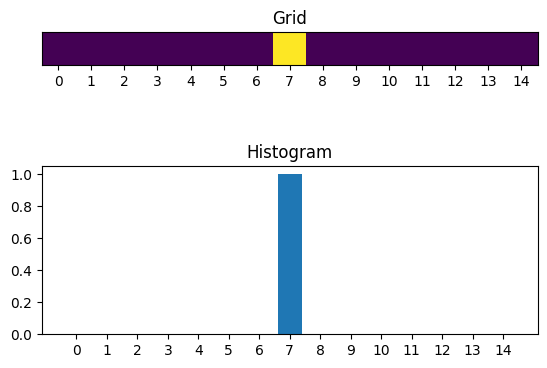

In [2]:
from utils import *

import matplotlib.pyplot as plt
%matplotlib inline

belief = np.zeros(15)

# initial known position
x_start = 7
belief[x_start] = 1.0

plot_belief(belief)

The plots above shows the initial belief about the position of the robot both as weights in the grid world and as a histogram.

**Tasks:**
1. Implement the motion model (`motion_model`) in the `utils.py` file and estimate recursively the belief about the position of the robot after executing the following sequence of commands:
$$ F, F, F, F, B, B, F, F, B $$
2. Plot the final belief using the `plot_belief` function.

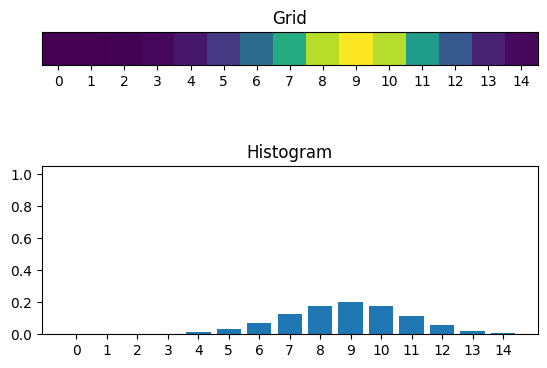

array([4.34490000e-05, 2.31841000e-04, 1.10588400e-03, 4.15951200e-03,
       1.30210440e-02, 3.32987040e-02, 7.14430260e-02, 1.24632668e-01,
       1.79596638e-01, 2.01458448e-01, 1.79240748e-01, 1.11120408e-01,
       5.51373480e-02, 1.99711750e-02, 5.53910700e-03])

In [3]:
# After implementing the function motion_model, write here the code required to recursively update the belief 
# after performing the indicated actions and plot the final belief.

actions = ['F', 'F', 'F', 'F', 'B', 'B', 'F', 'F', 'B']

belief_task1 = belief.copy()
for action in actions:
    belief_task1 = motion_model(action, belief_task1)

plot_belief(belief_task1)

belief_task1

### Interpretation

The grid and histogram show a wide, flattened probability distribution spread between cells 4 and 14. The highest peak is at cell **9**, but with a low confidence of only $0.2$ on the y-axis, while adjacent cells (8 and 10) are nearly as likely.

This visually demonstrates the flaw of pure dead reckoning. Due to the inherent noise in the motion model (0.7 correct, 0.2 no movement, 0.1 opposite), positional uncertainty compounds with each step. Without sensor feedback to correct this drift, the robot's belief spreads out, eventually leading to a complete loss of localization.

# **Bayes Filter**

Now, assume that we equipped the robot with a sensor which is able to recognize the color of the floor on which the robot navigates.

The floor can be either black **(0)** or white **(1)** and the environment looks as follows:

![gridworld_map](./pics/1d_gridworld_floor.png)

The map of the true floor colors is stored in `world.data`.

The sensor is able to recognize that:

- a tile is **white** with probability **0.7**. This is $P(W \mid W)$.
- a tile is **black** with probability **0.9**. This is $P(B \mid B)$.

The robot starts again in `7`. It executes the same commands as in the previous section and follows the same motion model.

During navigation, it makes the observations stored in `observations.data`.

Thanks to its new sensor, it can now use the observations to estimate its position in the world.

**Tasks:**
1. Implement the function `sensor_model` in the `utils.py`, which defines the sensor model.
2. Implement the `recursive_bayes_filter` function, which estimates recursively the belief about the position of the robot incorporating the observations.
3. Plot the final belief using the `plot_belief` function.
4. Print out the most likely position and the corresponding probability.

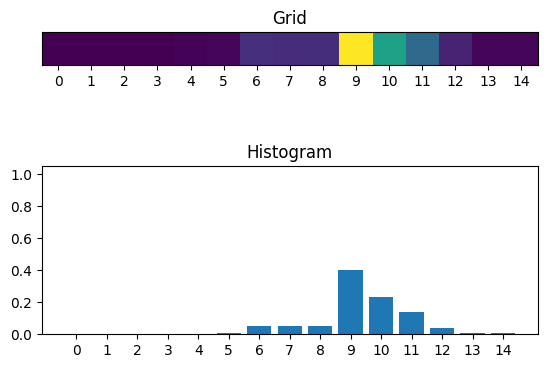

Most likely position: 9
Probability: 0.404549


array([5.07979666e-06, 8.37561733e-06, 7.77819441e-05, 6.15254673e-04,
       3.72680200e-03, 6.56156263e-03, 5.45692976e-02, 5.21246261e-02,
       5.26912566e-02, 4.04549138e-01, 2.31395536e-01, 1.39587231e-01,
       4.04889740e-02, 7.40574385e-03, 6.19334010e-03])

In [4]:
# After implementing the aforementioned functions, write here the code required to load the world and the observations
# and to apply the recursive bayes filter to compute the final belief. Plot this final belief and the most likely position.

actions = ['F', 'F', 'F', 'F', 'B', 'B', 'F', 'F', 'B']
world = np.loadtxt('./data/world.data', delimiter=',', dtype=int)
observations = np.loadtxt('./data/observations.data', delimiter=',', dtype=int)

belief = np.zeros(15)
belief[7] = 1.0

belief_bayes = recursive_bayes_filter(actions, observations, belief, world)
plot_belief(belief_bayes)

most_likely_pos = int(np.argmax(belief_bayes))
most_likely_prob = float(belief_bayes[most_likely_pos])

print(f"Most likely position: {most_likely_pos}")
print(f"Probability: {most_likely_prob:.6f}")

belief_bayes

### Interpretation

The grid now displays a highly concentrated bright cell at position 9. The histogram confirms this with a sharp, prominent peak reaching **40.4%** at cell **9**, with the probabilities of surrounding cells significantly reduced compared to the pure motion model.

This visually demonstrates the power of sensor fusion. The "update" step of the Bayes Filter actively corrects the accumulated dead-reckoning drift. By comparing the detected floor color with the ground truth map, the algorithm discards unlikely positions, reducing uncertainty and sharply anchoring the robot's belief to reality.

# **Bayes Filter with Unknown Initial Position**

What if the initial position of the robot is unknown?

**Tasks:**
1. Consider the same task as in the previous section, but with the initial belief about the position of the robot being an uniform probability distribution over the world, and plot the final belief about the position of the robot.
3. Print out the most likely position and the corresponding probability.

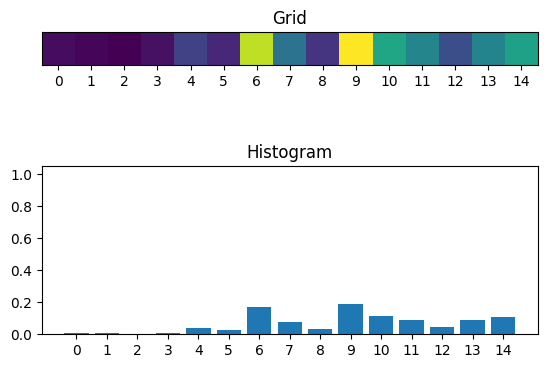

Most likely position: 9
Probability: 0.189480


array([0.00823867, 0.00539924, 0.00236149, 0.01066686, 0.03831869,
       0.02412404, 0.17171487, 0.07378504, 0.03157493, 0.18948021,
       0.11344569, 0.0877498 , 0.04707083, 0.08683494, 0.1092347 ])

In [5]:
# Write here the code to solve the exercise

actions = ['F', 'F', 'F', 'F', 'B', 'B', 'F', 'F', 'B']
world = np.loadtxt('./data/world.data', delimiter=',', dtype=int)
observations = np.loadtxt('./data/observations.data', delimiter=',', dtype=int)

belief_uniform = np.ones(15) / 15.0

belief_unknown_init = recursive_bayes_filter(actions, observations, belief_uniform, world)
plot_belief(belief_unknown_init)

most_likely_pos = int(np.argmax(belief_unknown_init))
most_likely_prob = float(belief_unknown_init[most_likely_pos])

print(f"Most likely position: {most_likely_pos}")
print(f"Probability: {most_likely_prob:.6f}")

belief_unknown_init

### Interpretation

The grid and histogram reveal a multi-modal distribution with several distinct probability peaks. The highest peak is located at cell **9**, reaching **18.9%**. However, a strong secondary peak appears at cell **6** (17.1%), and the probability mass is more distributed compared to the previous task.

This scenario perfectly illustrates global localization (the "kidnapped robot" problem). Starting from total ignorance, the robot relies entirely on the sequence of observations and movements to deduce its location. The multiple peaks occur because the map has repeating color patterns, making different areas look identical to the sensor. Despite this ambiguity, the Bayes Filter successfully accumulates enough information over time to identify the true position (cell 9) as the most probable candidate.

# **Testing Probabilistic Variations (Analysis)**

To better understand the individual impact of the motion and sensor models on the Bayes Filter, we will conduct three tests by varying the confidence probabilities. By parameterizing our functions, we can simulate extreme scenarios without altering the core logic in `utils.py`. 

In all tests, the robot starts at the known initial position (Cell 7) and executes the same sequence of actions. We will test:
1.  **Perfect Sensor:** Flawless observations, but noisy motion.
2.  **Perfect Motion:** Flawless deterministic movement, but noisy observations.
3.  **Useless Sensor:** A completely blind robot (50% accuracy).

--- Test 1: Perfect Sensor ---
Most likely position: 9 (Prob: 0.632015)


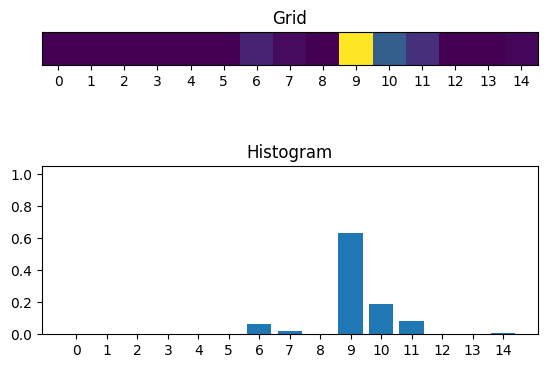

--- Test 2: Perfect Motion ---
Most likely position: 10 (Prob: 1.000000)


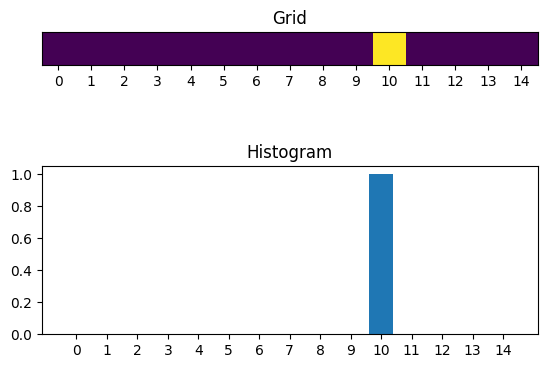

--- Test 3: Useless Sensor ---
Most likely position: 9 (Prob: 0.201458)


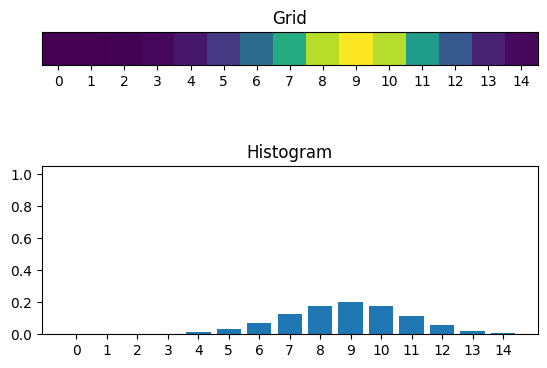

In [6]:
# --- PARAMETERIZED FUNCTIONS FOR TESTING ---
def parameterized_motion_model(action, belief, p_correct, p_stay, p_opposite):
    n_cells = belief.shape[0]
    new_belief = np.zeros_like(belief)
    
    correct_step = 1 if action == 'F' else -1
    opposite_step = -1 if action == 'F' else 1

    for x_prev, prob in enumerate(belief):
        x_correct, x_opposite = x_prev + correct_step, x_prev + opposite_step

        # Correct movement
        if 0 <= x_correct < n_cells: new_belief[x_correct] += p_correct * prob
        else: new_belief[x_prev] += p_correct * prob
            
        # Does not move
        new_belief[x_prev] += p_stay * prob
        
        # Opposite movement
        if 0 <= x_opposite < n_cells: new_belief[x_opposite] += p_opposite * prob
        else: new_belief[x_prev] += p_opposite * prob

    return new_belief

def parameterized_sensor_model(observation, belief, world, p_w_given_w, p_b_given_b):
    world = np.asarray(world).astype(int)
    if observation == 1: # White observed
        likelihood = np.where(world == 1, p_w_given_w, 1 - p_b_given_b)
    else: # Black observed
        likelihood = np.where(world == 0, p_b_given_b, 1 - p_w_given_w)
        
    updated_belief = belief * likelihood
    return updated_belief / np.sum(updated_belief)

def run_test(p_correct, p_stay, p_opposite, p_w_w, p_b_b, title):
    actions = ['F', 'F', 'F', 'F', 'B', 'B', 'F', 'F', 'B']
    world = np.loadtxt('./data/world.data', delimiter=',', dtype=int)
    observations = np.loadtxt('./data/observations.data', delimiter=',', dtype=int)
    
    current_belief = np.zeros(15)
    current_belief[7] = 1.0 # Starting at known position 7
    
    # Process initial observation if present
    if len(observations) == len(actions) + 1:
        current_belief = parameterized_sensor_model(observations[0], current_belief, world, p_w_w, p_b_b)
        obs_to_process = observations[1:]
    else:
        obs_to_process = observations
        
    for action, observation in zip(actions, obs_to_process):
        current_belief = parameterized_motion_model(action, current_belief, p_correct, p_stay, p_opposite)
        current_belief = parameterized_sensor_model(observation, current_belief, world, p_w_w, p_b_b)
        
    print(f"--- {title} ---")
    most_likely_pos = int(np.argmax(current_belief))
    print(f"Most likely position: {most_likely_pos} (Prob: {current_belief[most_likely_pos]:.6f})")
    plot_belief(current_belief)

# --- RUNNING THE TESTS ---

# Test 1: Perfect Sensor (No noise in measurements)
run_test(p_correct=0.7, p_stay=0.2, p_opposite=0.1, p_w_w=1.0, p_b_b=1.0, title="Test 1: Perfect Sensor")

# Test 2: Perfect Motion (No noise in actuators)
run_test(p_correct=1.0, p_stay=0.0, p_opposite=0.0, p_w_w=0.7, p_b_b=0.9, title="Test 2: Perfect Motion")

# Test 3: Useless Sensor (50% accuracy, essentially guessing)
run_test(p_correct=0.7, p_stay=0.2, p_opposite=0.1, p_w_w=0.5, p_b_b=0.5, title="Test 3: Useless Sensor")

### **Results Interpretation**

* **Test 1: Perfect Sensor (Flawless Observations)**
    * **Observation:** The peak probability at cell 9 rises to **63.2%**.
    * **Analysis:** A flawless sensor instantly eliminates impossible positions based on the ground truth. It dominates the filter, aggressively reducing the uncertainty caused by the noisy movement.

* **Test 2: Perfect Motion (Flawless Actuators)**
    * **Observation:** The belief collapses to **100%** at cell **10**, not cell 9.
    * **Analysis:** The ideal deterministic path from cell 7 (`F, F, F, F, B, B, F, F, B`) actually ends at cell 10. Our standard noisy model predicted cell 9 because the 20% chance of "not moving" causes the estimate to lag behind. Perfect motion eliminates this dead-reckoning drift entirely.

* **Test 3: Useless Sensor (Blind Robot)**
    * **Observation:** The distribution exactly matches the pure motion model (Task 1), peaking at **20.1%** at cell 9.
    * **Analysis:** A 50% accurate sensor acts like a coin toss, providing zero information gain. The Bayes Filter ignores these useless observations, and the system devolves entirely into pure dead-reckoning.